# 🌦️ Weather Intelligence — ML Temperature Prediction & Live Weather Dashboard

A cleaned version of the original project notebook. The original working model, historical analysis, live weather API, and professional Gradio dashboard are retained. Redundant/obsolete cells and broken 2017-only forecast experiments have been removed.

## 1. Project Setup & Historical Dataset

In [1]:
print("Weather Data Analysis and Prediction Project")
print("Starting the project...")


Weather Data Analysis and Prediction Project
Starting the project...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Download the weather dataset

import pandas as pd

url = "https://raw.githubusercontent.com/kristinlussi/607ExtraCredit3/main/DailyDelhiClimateTrain.csv"

df = pd.read_csv(url)

print("Dataset downloaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset downloaded successfully!
Shape of dataset: (1462, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
# Step 2: Understand the dataset

print("Dataset Information:")
print("=" * 40)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
display(df.describe())

Dataset Information:
Number of rows: 1462
Number of columns: 5

Column names:
['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

Data types:
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

Missing values:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Basic statistics:


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [5]:
# Step 3: Clean the weather data

import pandas as pd
import numpy as np

# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Find unrealistic pressure values
print("\nUnusual pressure values:")
print(df[(df['meanpressure'] < 900) | (df['meanpressure'] > 1100)][
    ['date', 'meanpressure']
])

# Replace unrealistic pressure values with NaN
df.loc[
    (df['meanpressure'] < 900) | (df['meanpressure'] > 1100),
    'meanpressure'
] = np.nan

# Interpolate missing pressure values
df['meanpressure'] = df['meanpressure'].interpolate()

# Check the result
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nData types after cleaning:")
print(df.dtypes)

print("\nCleaned dataset:")
display(df.head())

Duplicate rows: 0

Unusual pressure values:
           date  meanpressure
1182 2016-03-28   7679.333333
1309 2016-08-02    310.437500
1321 2016-08-14    633.900000
1323 2016-08-16     -3.041667
1362 2016-09-24   1352.615385
1416 2016-11-17   1350.296296
1427 2016-11-28     12.045455

Missing values after cleaning:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Data types after cleaning:
date            datetime64[ns]
meantemp               float64
humidity               float64
wind_speed             float64
meanpressure           float64
dtype: object

Cleaned dataset:


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


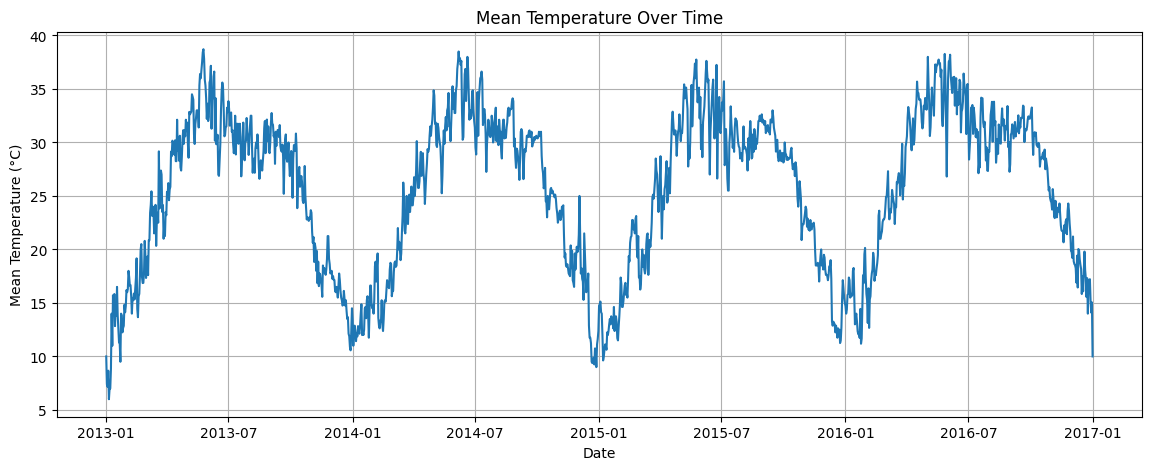

In [6]:
# Step 4: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt

# Set date as the index for easier time-series plotting
df_plot = df.set_index('date')

# Plot mean temperature over time
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['meantemp'])
plt.title('Mean Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.grid(True)
plt.show()

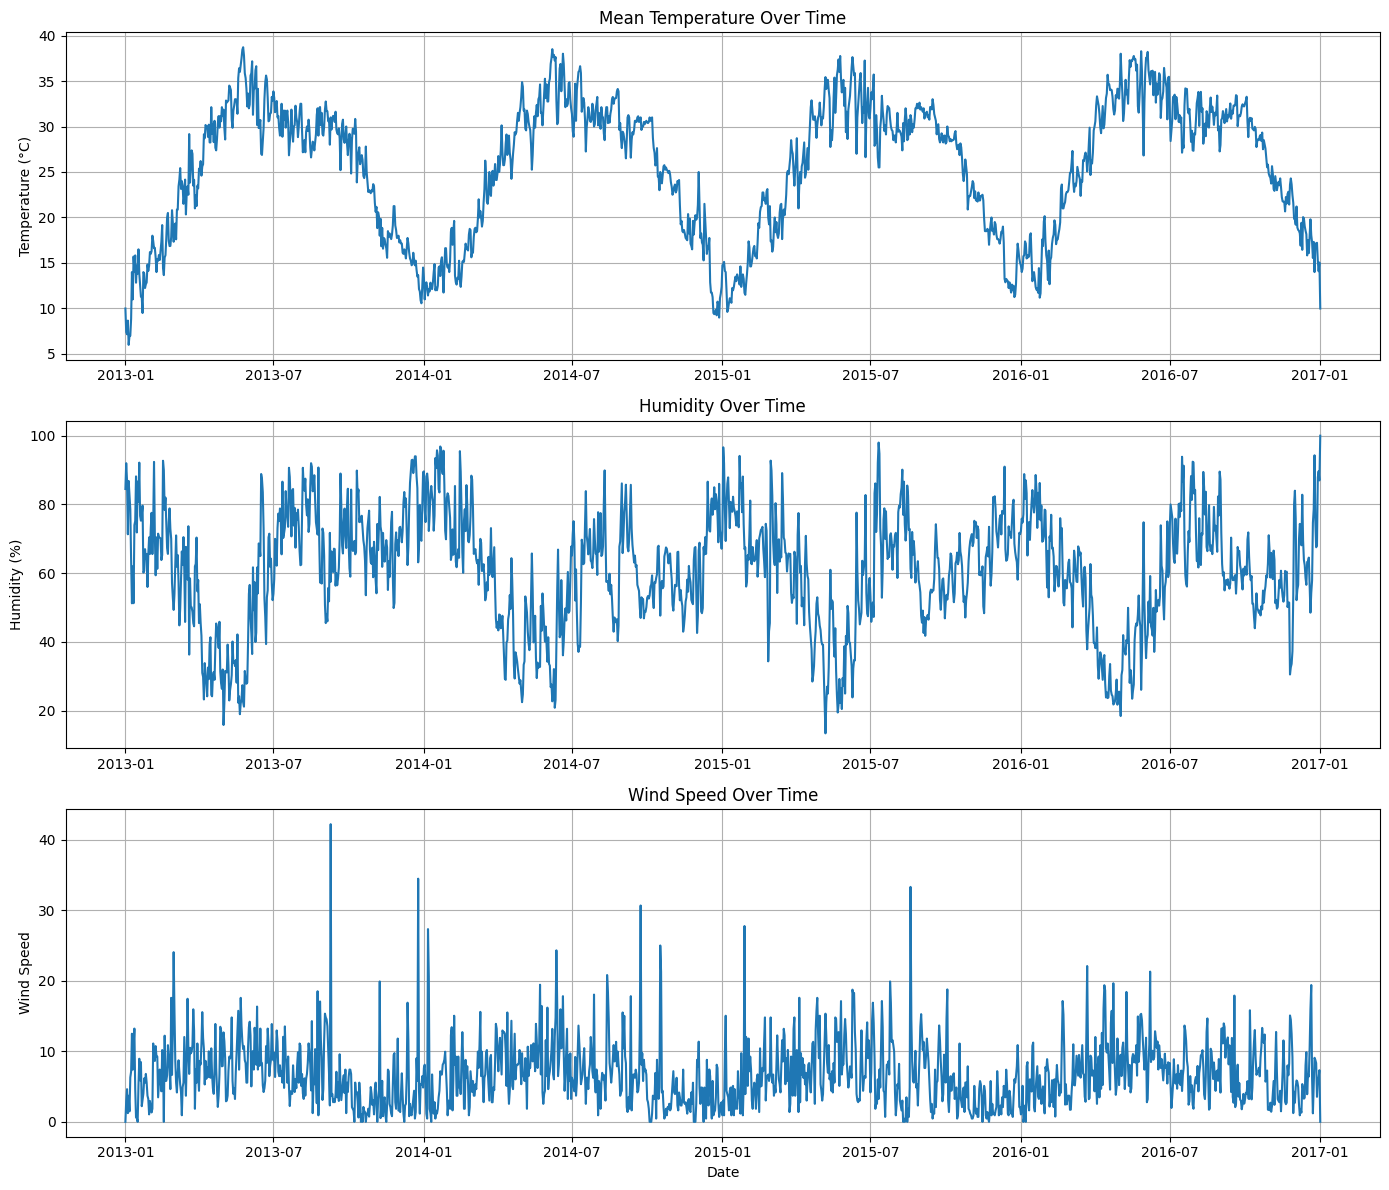

In [7]:
# Step 5: Visualize all weather variables

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Temperature
axes[0].plot(df_plot.index, df_plot['meantemp'])
axes[0].set_title('Mean Temperature Over Time')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True)

# Humidity
axes[1].plot(df_plot.index, df_plot['humidity'])
axes[1].set_title('Humidity Over Time')
axes[1].set_ylabel('Humidity (%)')
axes[1].grid(True)

# Wind Speed
axes[2].plot(df_plot.index, df_plot['wind_speed'])
axes[2].set_title('Wind Speed Over Time')
axes[2].set_ylabel('Wind Speed')
axes[2].set_xlabel('Date')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Correlation with Mean Temperature:
meantemp        1.000000
wind_speed      0.306468
humidity       -0.571951
meanpressure   -0.846820
Name: meantemp, dtype: float64


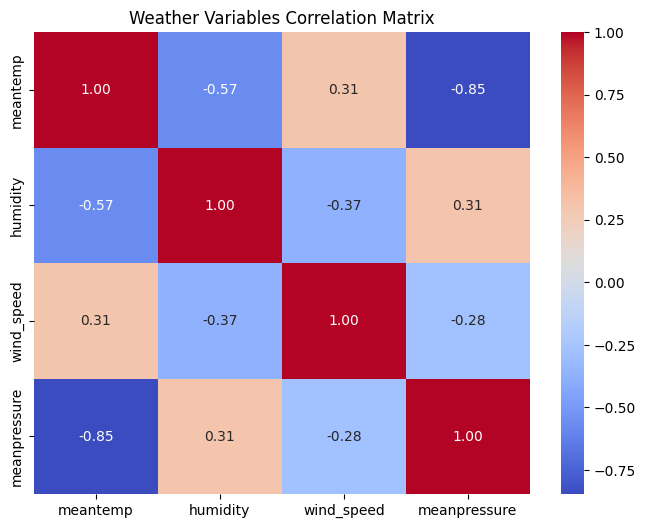

In [8]:
# Step 6: Correlation Analysis

# Select numerical columns
weather_numeric = df[
    ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
]

# Calculate correlations
correlation = weather_numeric.corr()

print("Correlation with Mean Temperature:")
print(correlation['meantemp'].sort_values(ascending=False))

# Display correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Weather Variables Correlation Matrix')
plt.show()

## 2. Final ML Model

The project uses the existing six-feature Random Forest pipeline: humidity, wind speed, atmospheric pressure, year, month, and day.

In [9]:
# ============================================
# STEP: CREATE DATE-BASED FEATURES
# ============================================

# Create a copy so our cleaned dataset remains unchanged
weather_model = df.copy()

# Extract useful information from the date
weather_model['year'] = weather_model['date'].dt.year
weather_model['month'] = weather_model['date'].dt.month
weather_model['day'] = weather_model['date'].dt.day

# Display the new dataset
print("New features added successfully!")
print("\nColumns:")
print(weather_model.columns.tolist())

print("\nFirst 5 rows:")
display(weather_model.head())

New features added successfully!

Columns:
['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure', 'year', 'month', 'day']

First 5 rows:


,date,meantemp,humidity,wind_speed,meanpressure,year,month,day
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1,2
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1,3
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1,4
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1,5


In [10]:
# ============================================
# STEP 2: IMPROVED RANDOM FOREST MODEL
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select features
X = weather_model[
    ['humidity', 'wind_speed', 'meanpressure', 'year', 'month', 'day']
]

# Target
y = weather_model['meantemp']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Create Random Forest model
rf_improved = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
rf_improved.fit(X_train, y_train)

# Predict
y_pred_improved = rf_improved.predict(X_test)

# Evaluate
mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print("\nImproved Random Forest Performance")
print("=" * 40)
print(f"Mean Absolute Error (MAE): {mae_improved:.2f} °C")
print(f"Root Mean Squared Error (RMSE): {rmse_improved:.2f} °C")
print(f"R² Score: {r2_improved:.2f}")

Training data: (1169, 6)
Testing data: (293, 6)

Improved Random Forest Performance
Mean Absolute Error (MAE): 1.21 °C
Root Mean Squared Error (RMSE): 1.57 °C
R² Score: 0.95


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [12]:
# ============================================================
# FINAL RANDOM FOREST EVALUATION
# ============================================================

final_predictions = rf_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_r2 = r2_score(y_test, final_predictions)

print("=" * 60)
print("        FINAL RANDOM FOREST MODEL PERFORMANCE")
print("=" * 60)
print(f"R² Score               : {final_r2:.4f}")
print(f"Mean Absolute Error    : {final_mae:.4f} °C")
print(f"Root Mean Square Error : {final_rmse:.4f} °C")
print("-" * 60)
print("Features:", list(X_train.columns))
print("Training records:", len(X_train))
print("Testing records :", len(X_test))
print("=" * 60)


        FINAL RANDOM FOREST MODEL PERFORMANCE
R² Score               : 0.9544
Mean Absolute Error    : 1.2087 °C
Root Mean Square Error : 1.5660 °C
------------------------------------------------------------
Features: ['humidity', 'wind_speed', 'meanpressure', 'year', 'month', 'day']
Training records: 1169
Testing records : 293


,Actual Temperature (°C),Predicted Temperature (°C)
0,35.88,35.46
1,18.00,16.71
2,15.25,17.06
3,38.50,37.41
4,24.00,22.56
5,31.00,30.62
6,28.38,28.47
7,23.71,24.12
8,26.00,28.81
9,35.00,35.28


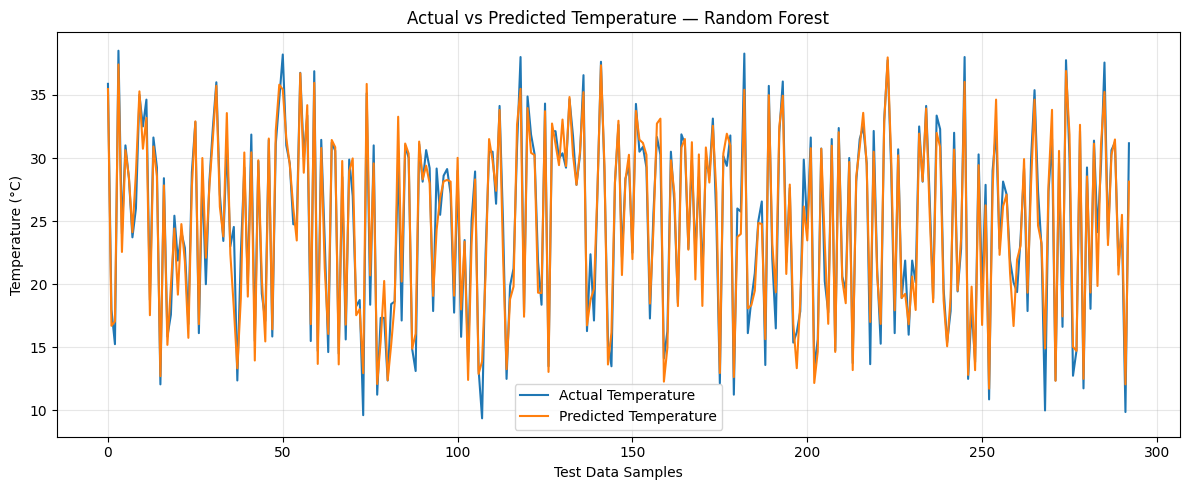

In [13]:
# ============================================================
# ACTUAL vs PREDICTED TEMPERATURE
# ============================================================

comparison_df = pd.DataFrame({
    "Actual Temperature (°C)": y_test.values,
    "Predicted Temperature (°C)": final_predictions
})

display(comparison_df.head(10).round(2))

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual Temperature")
plt.plot(final_predictions, label="Predicted Temperature")
plt.title("Actual vs Predicted Temperature — Random Forest")
plt.xlabel("Test Data Samples")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Feature Importance:
        Feature  Importance
2  meanpressure    0.831001
0      humidity    0.071173
4         month    0.055564
5           day    0.018470
3          year    0.014200
1    wind_speed    0.009591


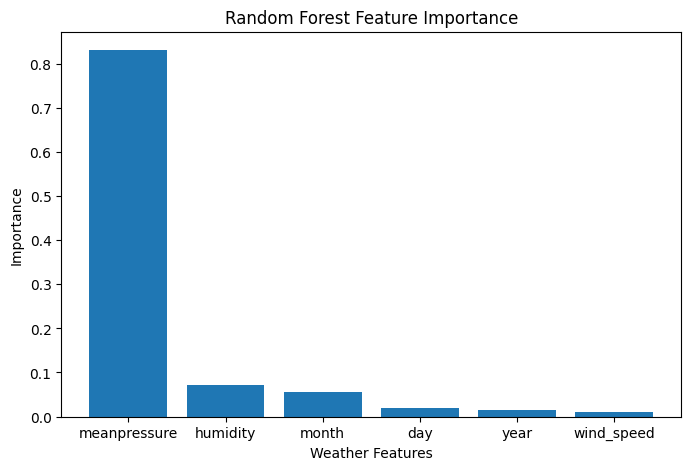

In [14]:
# ==========================================
# FEATURE IMPORTANCE - RANDOM FOREST
# ==========================================

# Get feature importance
importance = rf_model.feature_importances_

# Create a dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Weather Features')
plt.ylabel('Importance')

plt.show()

In [15]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import joblib

MODEL_PATH = "weather_random_forest_model.pkl"
FEATURES_PATH = "weather_model_features.pkl"

joblib.dump(rf_model, MODEL_PATH)
joblib.dump(list(X_train.columns), FEATURES_PATH)

print("=" * 60)
print("          MODEL SAVING COMPLETED")
print("=" * 60)
print("Model saved as:", MODEL_PATH)
print("Features saved as:", FEATURES_PATH)
print("Features:", list(X_train.columns))


          MODEL SAVING COMPLETED
Model saved as: weather_random_forest_model.pkl
Features saved as: weather_model_features.pkl
Features: ['humidity', 'wind_speed', 'meanpressure', 'year', 'month', 'day']


In [16]:
import joblib
import pandas as pd

print("=" * 60)
print("             SAVED MODEL VERIFICATION")
print("=" * 60)

# Load the saved model
loaded_model = joblib.load("weather_random_forest_model.pkl")

print("\nModel loaded successfully!")
print("Model type:", type(loaded_model).__name__)

# Display expected features
print("\nExpected features:")
print(list(loaded_model.feature_names_in_))

# Create test input with the SAME feature names used during training
test_input = pd.DataFrame([{
    "humidity": 70,
    "wind_speed": 5,
    "meanpressure": 1015,
    "year": 2017,
    "month": 1,
    "day": 2
}])

# Make prediction
test_prediction = loaded_model.predict(test_input)

print("\nTest prediction:")
print(f"Temperature = {test_prediction[0]:.2f} °C")

print("\nModel verification completed successfully! ✅")

             SAVED MODEL VERIFICATION

Model loaded successfully!
Model type: RandomForestRegressor

Expected features:
['humidity', 'wind_speed', 'meanpressure', 'year', 'month', 'day']

Test prediction:
Temperature = 16.85 °C

Model verification completed successfully! ✅


## 3. Live Weather & Live 7-Day Forecast

In [17]:
# ============================================================
#              LIVE CURRENT WEATHER + ML PREDICTION
# ============================================================

import requests
import pandas as pd
from datetime import datetime

print("=" * 60)
print("        LIVE WEATHER + ML TEMPERATURE PREDICTION")
print("=" * 60)

# ------------------------------------------------------------
# ENTER YOUR CITY
# ------------------------------------------------------------
city = input("Enter your city name: ")

# ------------------------------------------------------------
# GET CITY COORDINATES
# ------------------------------------------------------------
geo_url = "https://geocoding-api.open-meteo.com/v1/search"

geo_params = {
    "name": city,
    "count": 1,
    "language": "en",
    "format": "json"
}

geo_response = requests.get(geo_url, params=geo_params)
geo_data = geo_response.json()

if "results" not in geo_data:
    print("\nCity not found. Please check the city name.")
else:
    location = geo_data["results"][0]

    latitude = location["latitude"]
    longitude = location["longitude"]
    city_name = location["name"]
    country = location.get("country", "")

    print(f"\nLocation: {city_name}, {country}")
    print(f"Latitude: {latitude}")
    print(f"Longitude: {longitude}")

    # --------------------------------------------------------
    # GET CURRENT WEATHER
    # --------------------------------------------------------
    weather_url = "https://api.open-meteo.com/v1/forecast"

    weather_params = {
        "latitude": latitude,
        "longitude": longitude,
        "current": [
            "temperature_2m",
            "relative_humidity_2m",
            "wind_speed_10m",
            "pressure_msl"
        ],
        "timezone": "auto"
    }

    weather_response = requests.get(
        weather_url,
        params=weather_params
    )

    weather_data = weather_response.json()

    current = weather_data["current"]

    # --------------------------------------------------------
    # CURRENT WEATHER VALUES
    # --------------------------------------------------------
    actual_temperature = current["temperature_2m"]
    humidity = current["relative_humidity_2m"]
    wind_speed = current["wind_speed_10m"]
    pressure = current["pressure_msl"]

    current_time = current["time"]

    print("\n" + "=" * 60)
    print("                 CURRENT WEATHER")
    print("=" * 60)

    print(f"\nTime: {current_time}")
    print(f"Actual Temperature: {actual_temperature:.2f} °C")
    print(f"Humidity: {humidity:.2f} %")
    print(f"Wind Speed: {wind_speed:.2f} km/h")
    print(f"Pressure: {pressure:.2f} hPa")

    # --------------------------------------------------------
    # PREPARE INPUT FOR YOUR RANDOM FOREST MODEL
    # --------------------------------------------------------
    current_datetime = pd.to_datetime(current_time)

    ml_input = pd.DataFrame([{
        "humidity": humidity,
        "wind_speed": wind_speed,
        "meanpressure": pressure,
        "year": current_datetime.year,
        "month": current_datetime.month,
        "day": current_datetime.day
    }])

    # --------------------------------------------------------
    # ML TEMPERATURE PREDICTION
    # --------------------------------------------------------
    ml_prediction = loaded_model.predict(ml_input)[0]

    print("\n" + "=" * 60)
    print("             MACHINE LEARNING RESULT")
    print("=" * 60)

    print(f"\nML Predicted Temperature: {ml_prediction:.2f} °C")

    print("\n" + "=" * 60)
    print("       LIVE WEATHER PREDICTION COMPLETED! ✅")
    print("=" * 60)

        LIVE WEATHER + ML TEMPERATURE PREDICTION
Enter your city name: delhi

Location: Delhi, India
Latitude: 28.65195
Longitude: 77.23149

                 CURRENT WEATHER

Time: 2026-08-30T10:15
Actual Temperature: 33.20 °C
Humidity: 54.00 %
Wind Speed: 10.20 km/h
Pressure: 1003.10 hPa

             MACHINE LEARNING RESULT

ML Predicted Temperature: 32.63 °C

       LIVE WEATHER PREDICTION COMPLETED! ✅


In [18]:
# ============================================================
#              LIVE 7-DAY ML TEMPERATURE FORECAST
# ============================================================

import requests
import pandas as pd
import numpy as np

print("=" * 60)
print("             LIVE 7-DAY WEATHER FORECAST")
print("=" * 60)

# ------------------------------------------------------------
# ENTER CITY
# ------------------------------------------------------------
city = input("Enter your city name: ")

# ------------------------------------------------------------
# FIND CITY COORDINATES
# ------------------------------------------------------------
geo_url = "https://geocoding-api.open-meteo.com/v1/search"

geo_params = {
    "name": city,
    "count": 1,
    "language": "en",
    "format": "json"
}

geo_response = requests.get(geo_url, params=geo_params)
geo_data = geo_response.json()

if "results" not in geo_data:
    print("\nCity not found. Please check the city name.")

else:
    location = geo_data["results"][0]

    latitude = location["latitude"]
    longitude = location["longitude"]
    city_name = location["name"]
    country = location.get("country", "")

    print(f"\nLocation: {city_name}, {country}")

    # --------------------------------------------------------
    # GET 7-DAY WEATHER FORECAST
    # --------------------------------------------------------
    weather_url = "https://api.open-meteo.com/v1/forecast"

    weather_params = {
        "latitude": latitude,
        "longitude": longitude,
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "relative_humidity_2m_mean",
            "wind_speed_10m_max",
            "pressure_msl_mean"
        ],
        "timezone": "auto",
        "forecast_days": 7
    }

    weather_response = requests.get(
        weather_url,
        params=weather_params
    )

    weather_data = weather_response.json()

    daily = weather_data["daily"]

    # --------------------------------------------------------
    # CREATE FORECAST DATAFRAME
    # --------------------------------------------------------
    forecast_input = pd.DataFrame({
        "date": pd.to_datetime(daily["time"]),
        "humidity": daily["relative_humidity_2m_mean"],
        "wind_speed": daily["wind_speed_10m_max"],
        "meanpressure": daily["pressure_msl_mean"]
    })

    # --------------------------------------------------------
    # CREATE DATE FEATURES REQUIRED BY MODEL
    # --------------------------------------------------------
    forecast_input["year"] = forecast_input["date"].dt.year
    forecast_input["month"] = forecast_input["date"].dt.month
    forecast_input["day"] = forecast_input["date"].dt.day

    # --------------------------------------------------------
    # ML PREDICTION
    # --------------------------------------------------------
    ml_predictions = loaded_model.predict(
        forecast_input[
            [
                "humidity",
                "wind_speed",
                "meanpressure",
                "year",
                "month",
                "day"
            ]
        ]
    )

    # --------------------------------------------------------
    # CREATE FINAL RESULT
    # --------------------------------------------------------
    result = pd.DataFrame({
        "Date": forecast_input["date"].dt.strftime("%Y-%m-%d"),
        "API Max Temp (°C)": np.round(
            daily["temperature_2m_max"], 2
        ),
        "API Min Temp (°C)": np.round(
            daily["temperature_2m_min"], 2
        ),
        "ML Predicted Temp (°C)": np.round(
            ml_predictions, 2
        )
    })

    print("\n" + "=" * 60)
    print("              7-DAY FORECAST")
    print("=" * 60)

    print("\n")
    print(result.to_string(index=False))

    print("\n" + "=" * 60)
    print("       LIVE 7-DAY FORECAST COMPLETED! ✅")
    print("=" * 60)

             LIVE 7-DAY WEATHER FORECAST
Enter your city name: delhi

Location: Delhi, India

              7-DAY FORECAST


      Date  API Max Temp (°C)  API Min Temp (°C)  ML Predicted Temp (°C)
2026-08-30               36.6               28.2                   33.95
2026-08-31               36.9               27.9                   33.95
2026-09-01               35.6               28.3                   32.37
2026-09-02               30.5               25.1                   27.37
2026-09-03               29.6               25.2                   26.83
2026-09-04               28.8               25.8                   26.60
2026-09-05               30.9               24.8                   27.39

       LIVE 7-DAY FORECAST COMPLETED! ✅


## 4. Final Weather Visualizations

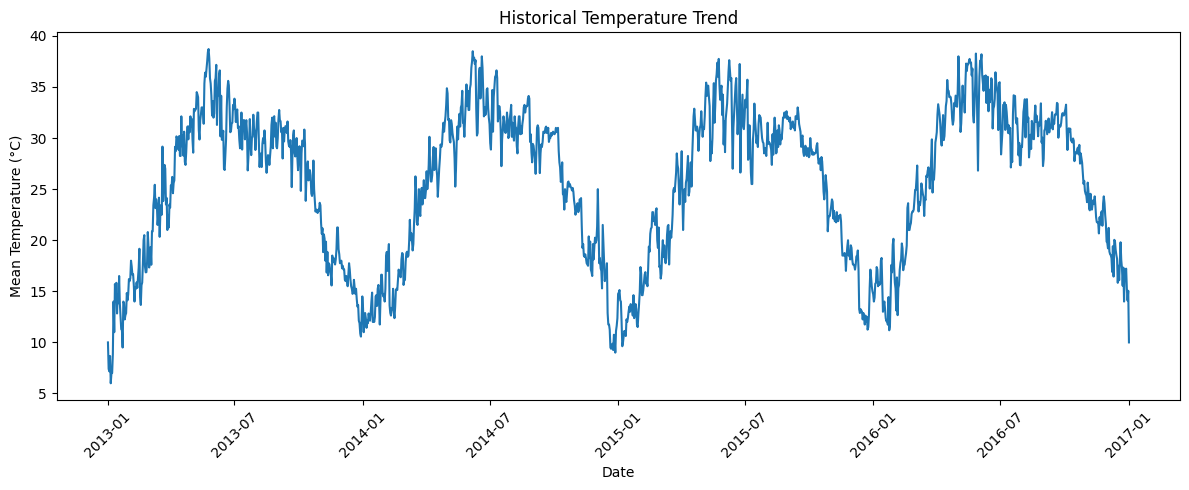

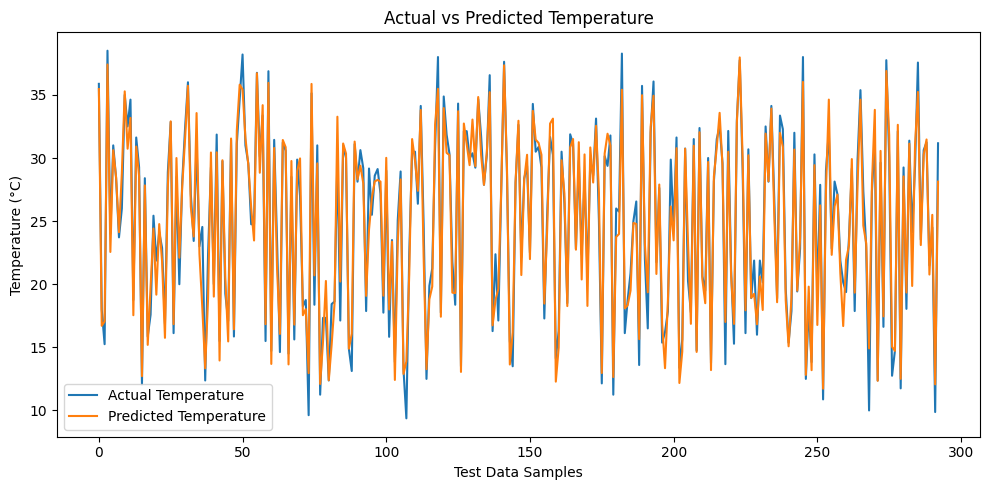

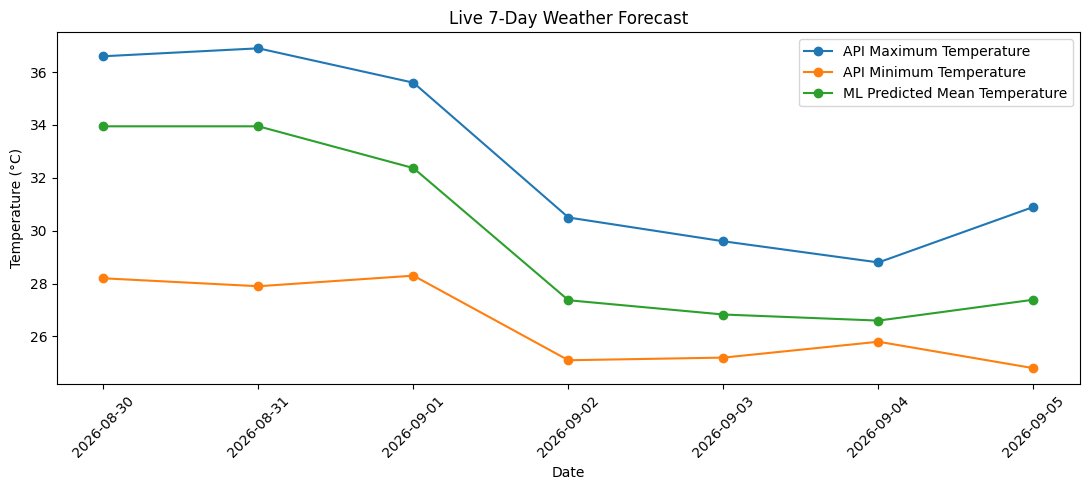

In [19]:
# ============================================================
#                 WEATHER VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GRAPH 1: HISTORICAL TEMPERATURE TREND
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["meantemp"]
)

plt.title("Historical Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GRAPH 2: ACTUAL VS PREDICTED TEMPERATURE
# ------------------------------------------------------------

# Use the same train/test split from your model
X_test_current = X_test.copy()
y_test_current = y_test.copy()

test_predictions = loaded_model.predict(X_test_current)

plt.figure(figsize=(10, 5))

plt.plot(
    y_test_current.values,
    label="Actual Temperature"
)

plt.plot(
    test_predictions,
    label="Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Data Samples")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GRAPH 3: LIVE 7-DAY FORECAST
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    pd.to_datetime(result["Date"]),
    result["API Max Temp (°C)"],
    marker="o",
    label="API Maximum Temperature"
)

plt.plot(
    pd.to_datetime(result["Date"]),
    result["API Min Temp (°C)"],
    marker="o",
    label="API Minimum Temperature"
)

plt.plot(
    pd.to_datetime(result["Date"]),
    result["ML Predicted Temp (°C)"],
    marker="o",
    label="ML Predicted Mean Temperature"
)

plt.title("Live 7-Day Weather Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Professional Gradio Dashboard

In [20]:
# ============================================================
#        PROFESSIONAL WEATHER PREDICTION DASHBOARD
# ============================================================

import gradio as gr
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# ------------------------------------------------------------
# CHECK MODEL
# ------------------------------------------------------------

if "loaded_model" not in globals():
    import joblib
    loaded_model = joblib.load("weather_random_forest_model.pkl")


# ------------------------------------------------------------
# MODEL PERFORMANCE
# ------------------------------------------------------------

model_metrics = {
    "MAE": "N/A",
    "RMSE": "N/A",
    "R² Score": "N/A"
}

try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    if "X_test_current" in globals() and "y_test_current" in globals():

        dashboard_predictions = loaded_model.predict(X_test_current)

        mae = mean_absolute_error(
            y_test_current,
            dashboard_predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test_current,
                dashboard_predictions
            )
        )

        r2 = r2_score(
            y_test_current,
            dashboard_predictions
        )

        model_metrics = {
            "MAE": f"{mae:.2f} °C",
            "RMSE": f"{rmse:.2f} °C",
            "R² Score": f"{r2:.3f}"
        }

except Exception:
    pass


# ------------------------------------------------------------
# WEATHER CODE DESCRIPTION
# ------------------------------------------------------------

def weather_description(code):

    weather_codes = {
        0: "Clear Sky",
        1: "Mainly Clear",
        2: "Partly Cloudy",
        3: "Overcast",
        45: "Foggy",
        48: "Depositing Rime Fog",
        51: "Light Drizzle",
        53: "Moderate Drizzle",
        55: "Dense Drizzle",
        56: "Freezing Drizzle",
        57: "Dense Freezing Drizzle",
        61: "Light Rain",
        63: "Moderate Rain",
        65: "Heavy Rain",
        66: "Freezing Rain",
        67: "Heavy Freezing Rain",
        71: "Light Snow",
        73: "Moderate Snow",
        75: "Heavy Snow",
        77: "Snow Grains",
        80: "Light Rain Showers",
        81: "Moderate Rain Showers",
        82: "Violent Rain Showers",
        85: "Light Snow Showers",
        86: "Heavy Snow Showers",
        95: "Thunderstorm",
        96: "Thunderstorm with Hail",
        99: "Severe Thunderstorm with Hail"
    }

    return weather_codes.get(code, "Weather Data Available")


# ------------------------------------------------------------
# MAIN WEATHER FUNCTION
# ------------------------------------------------------------

def get_weather(city):

    if city is None or city.strip() == "":
        return (
            "⚠️ **Please enter a city name.**",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            pd.DataFrame(),
            None
        )

    city = city.strip()

    try:

        # ====================================================
        # GEOCODING
        # ====================================================

        geo_url = "https://geocoding-api.open-meteo.com/v1/search"

        geo_params = {
            "name": city,
            "count": 1,
            "language": "en",
            "format": "json"
        }

        geo_response = requests.get(
            geo_url,
            params=geo_params,
            timeout=10
        )

        geo_data = geo_response.json()

        if "results" not in geo_data:
            return (
                f"❌ **City '{city}' was not found.** Please try another city.",
                "—",
                "—",
                "—",
                "—",
                "—",
                "—",
                pd.DataFrame(),
                None
            )

        location = geo_data["results"][0]

        latitude = location["latitude"]
        longitude = location["longitude"]

        city_name = location["name"]
        country = location.get("country", "")

        # ====================================================
        # CURRENT + DAILY WEATHER
        # ====================================================

        weather_url = "https://api.open-meteo.com/v1/forecast"

        weather_params = {
            "latitude": latitude,
            "longitude": longitude,

            "current": [
                "temperature_2m",
                "relative_humidity_2m",
                "wind_speed_10m",
                "pressure_msl",
                "weather_code"
            ],

            "daily": [
                "temperature_2m_max",
                "temperature_2m_min",
                "relative_humidity_2m_mean",
                "wind_speed_10m_max",
                "pressure_msl_mean"
            ],

            "timezone": "auto",
            "forecast_days": 7
        }

        weather_response = requests.get(
            weather_url,
            params=weather_params,
            timeout=10
        )

        weather_data = weather_response.json()

        current = weather_data["current"]
        daily = weather_data["daily"]

        # ====================================================
        # CURRENT VALUES
        # ====================================================

        actual_temperature = current["temperature_2m"]

        humidity = current["relative_humidity_2m"]

        wind_speed = current["wind_speed_10m"]

        pressure = current["pressure_msl"]

        weather_code = current["weather_code"]

        current_time = current["time"]

        condition = weather_description(weather_code)

        # ====================================================
        # ML CURRENT TEMPERATURE PREDICTION
        # ====================================================

        current_datetime = pd.to_datetime(current_time)

        ml_input = pd.DataFrame([{
            "humidity": humidity,
            "wind_speed": wind_speed,
            "meanpressure": pressure,
            "year": current_datetime.year,
            "month": current_datetime.month,
            "day": current_datetime.day
        }])

        ml_prediction = loaded_model.predict(
            ml_input
        )[0]

        difference = abs(
            actual_temperature - ml_prediction
        )

        # ====================================================
        # CURRENT WEATHER SUMMARY
        # ====================================================

        location_text = f"""
### 📍 {city_name}, {country}

**{condition}** · Updated **{current_time.replace("T", " ")}**
"""

        actual_text = f"""
# {actual_temperature:.1f} °C

### Current Temperature
"""

        ml_text = f"""
# {ml_prediction:.1f} °C

### ML Predicted Temperature

Difference from live value: **{difference:.1f} °C**
"""

        humidity_text = f"""
## 💧 {humidity:.0f}%

**Humidity**
"""

        wind_text = f"""
## 💨 {wind_speed:.1f} km/h

**Wind Speed**
"""

        pressure_text = f"""
## 🌬️ {pressure:.1f} hPa

**Pressure**
"""

        condition_text = f"""
## ☁️ {condition}

**Current Condition**
"""

        # ====================================================
        # 7-DAY DATA
        # ====================================================

        forecast_input = pd.DataFrame({
            "date": pd.to_datetime(daily["time"]),
            "humidity": daily["relative_humidity_2m_mean"],
            "wind_speed": daily["wind_speed_10m_max"],
            "meanpressure": daily["pressure_msl_mean"]
        })

        forecast_input["year"] = (
            forecast_input["date"].dt.year
        )

        forecast_input["month"] = (
            forecast_input["date"].dt.month
        )

        forecast_input["day"] = (
            forecast_input["date"].dt.day
        )

        feature_columns = [
            "humidity",
            "wind_speed",
            "meanpressure",
            "year",
            "month",
            "day"
        ]

        ml_forecast = loaded_model.predict(
            forecast_input[feature_columns]
        )

        # ====================================================
        # FINAL FORECAST TABLE
        # ====================================================

        forecast_df = pd.DataFrame({

            "Date": forecast_input["date"].dt.strftime(
                "%d %b"
            ),

            "Min °C": np.round(
                daily["temperature_2m_min"],
                1
            ),

            "Max °C": np.round(
                daily["temperature_2m_max"],
                1
            ),

            "ML Mean °C": np.round(
                ml_forecast,
                1
            )
        })

        # ====================================================
        # FORECAST GRAPH
        # ====================================================

        fig, ax = plt.subplots(
            figsize=(10, 4.5)
        )

        dates = pd.to_datetime(
            forecast_df["Date"],
            format="%d %b"
        )

        # Use actual dates from original forecast
        plot_dates = forecast_input["date"]

        ax.plot(
            plot_dates,
            daily["temperature_2m_max"],
            marker="o",
            linewidth=2,
            label="Forecast Max"
        )

        ax.plot(
            plot_dates,
            daily["temperature_2m_min"],
            marker="o",
            linewidth=2,
            label="Forecast Min"
        )

        ax.plot(
            plot_dates,
            ml_forecast,
            marker="o",
            linewidth=2,
            label="ML Mean Prediction"
        )

        ax.set_title(
            f"7-Day Weather Forecast — {city_name}"
        )

        ax.set_xlabel("Date")

        ax.set_ylabel(
            "Temperature (°C)"
        )

        ax.legend()

        ax.grid(
            alpha=0.25
        )

        plt.xticks(
            rotation=30
        )

        plt.tight_layout()

        return (
            location_text,
            actual_text,
            ml_text,
            humidity_text,
            wind_text,
            pressure_text,
            condition_text,
            forecast_df,
            fig
        )

    except Exception as e:

        return (
            f"❌ **Unable to retrieve weather data.**\n\n"
            f"Error: `{str(e)}`",
            "—",
            "—",
            "—",
            "—",
            "—",
            "—",
            pd.DataFrame(),
            None
        )


# ============================================================
# CUSTOM CSS
# ============================================================

custom_css = """

/* ---------- GLOBAL ---------- */

.gradio-container {
    max-width: 1250px !important;
    margin: auto !important;
    background:
        radial-gradient(
            circle at top left,
            rgba(56, 189, 248, 0.13),
            transparent 30%
        ),
        radial-gradient(
            circle at top right,
            rgba(99, 102, 241, 0.12),
            transparent 28%
        ),
        #07111f !important;
}


/* ---------- HEADER ---------- */

.hero {
    text-align: center;
    padding: 38px 25px 30px 25px;
    border-radius: 24px;
    margin-bottom: 22px;

    background:
        linear-gradient(
            135deg,
            rgba(14, 165, 233, 0.20),
            rgba(30, 41, 59, 0.80)
        );

    border: 1px solid rgba(148, 163, 184, 0.18);

    box-shadow:
        0 20px 60px rgba(0,0,0,0.28);
}

.hero-title {
    font-size: 42px;
    font-weight: 800;
    letter-spacing: -1px;
    margin-bottom: 8px;

    background:
        linear-gradient(
            90deg,
            #ffffff,
            #7dd3fc,
            #a5b4fc
        );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
}

.hero-subtitle {
    color: #cbd5e1;
    font-size: 17px;
    line-height: 1.6;
}


/* ---------- SEARCH ---------- */

.search-box {
    padding: 18px;
    border-radius: 18px;

    background: rgba(15, 23, 42, 0.75);

    border:
        1px solid
        rgba(148, 163, 184, 0.15);
}


/* ---------- WEATHER CARDS ---------- */

.weather-card {
    padding: 24px;
    min-height: 120px;

    border-radius: 20px;

    background:
        linear-gradient(
            145deg,
            rgba(15, 23, 42, 0.95),
            rgba(30, 41, 59, 0.80)
        );

    border:
        1px solid
        rgba(148, 163, 184, 0.14);

    box-shadow:
        0 12px 35px rgba(0,0,0,0.22);
}

.weather-card h1 {
    color: #f8fafc !important;
}

.weather-card h2 {
    color: #e2e8f0 !important;
}

.weather-card h3 {
    color: #94a3b8 !important;
}


/* ---------- SECTION HEADINGS ---------- */

.section-title {
    font-size: 24px;
    font-weight: 750;
    color: #f8fafc;
    margin-top: 18px;
    margin-bottom: 12px;
}


/* ---------- BUTTON ---------- */

.primary-btn {
    border-radius: 14px !important;
    font-size: 16px !important;
    font-weight: 700 !important;
    min-height: 48px !important;
}


/* ---------- TABLE ---------- */

table {
    border-radius: 14px !important;
    overflow: hidden !important;
}


/* ---------- FOOTER ---------- */

.footer {
    text-align: center;
    padding: 25px 10px;
    color: #94a3b8;
    font-size: 13px;
}

.footer strong {
    color: #cbd5e1;
}


/* ---------- MOBILE ---------- */

@media (max-width: 700px) {

    .hero-title {
        font-size: 30px;
    }

    .hero-subtitle {
        font-size: 14px;
    }

}

"""


# ============================================================
# BUILD GRADIO APP
# ============================================================

with gr.Blocks(
    title="Weather Intelligence Dashboard"
) as demo:

    # --------------------------------------------------------
    # HERO
    # --------------------------------------------------------

    gr.HTML("""
    <div class="hero">

        <div class="hero-title">
            🌦️ Weather Intelligence Dashboard
        </div>

        <div class="hero-subtitle">
            Real-time weather insights powered by
            <strong>Machine Learning + Live Weather Data</strong>
        </div>

    </div>
    """)

    # --------------------------------------------------------
    # SEARCH
    # --------------------------------------------------------

    with gr.Row(elem_classes="search-box"):

        city_input = gr.Textbox(
            label="📍 Enter City",
            placeholder="Example: Bengaluru",
            value="Bengaluru",
            scale=4
        )

        search_btn = gr.Button(
            "🔍 Analyze Weather",
            variant="primary",
            scale=1,
            elem_classes="primary-btn"
        )

    location_output = gr.Markdown()

    # --------------------------------------------------------
    # CURRENT WEATHER
    # --------------------------------------------------------

    gr.HTML("""
    <div class="section-title">
        🌤️ Current Weather
    </div>
    """)

    with gr.Row():

        with gr.Column(
            elem_classes="weather-card"
        ):
            actual_output = gr.Markdown()

        with gr.Column(
            elem_classes="weather-card"
        ):
            ml_output = gr.Markdown()

    with gr.Row():

        with gr.Column(
            elem_classes="weather-card"
        ):
            humidity_output = gr.Markdown()

        with gr.Column(
            elem_classes="weather-card"
        ):
            wind_output = gr.Markdown()

        with gr.Column(
            elem_classes="weather-card"
        ):
            pressure_output = gr.Markdown()

        with gr.Column(
            elem_classes="weather-card"
        ):
            condition_output = gr.Markdown()

    # --------------------------------------------------------
    # FORECAST
    # --------------------------------------------------------

    gr.HTML("""
    <div class="section-title">
        📅 7-Day Forecast
    </div>
    """)

    forecast_table = gr.Dataframe(
        headers=[
            "Date",
            "Min °C",
            "Max °C",
            "ML Mean °C"
        ],
        datatype=[
            "str",
            "number",
            "number",
            "number"
        ],
        interactive=False,
        wrap=True
    )

    forecast_plot = gr.Plot(
        label="Temperature Forecast"
    )

    # --------------------------------------------------------
    # MODEL PERFORMANCE
    # --------------------------------------------------------

    gr.HTML("""
    <div class="section-title">
        🤖 Machine Learning Model
    </div>
    """)

    with gr.Row():

        with gr.Column(
            elem_classes="weather-card"
        ):
            gr.Markdown(
                f"""
## 🎯 MAE

### {model_metrics["MAE"]}

Mean Absolute Error
"""
            )

        with gr.Column(
            elem_classes="weather-card"
        ):
            gr.Markdown(
                f"""
## 📐 RMSE

### {model_metrics["RMSE"]}

Root Mean Squared Error
"""
            )

        with gr.Column(
            elem_classes="weather-card"
        ):
            gr.Markdown(
                f"""
## ⭐ R² Score

### {model_metrics["R² Score"]}

Model explanatory power
"""
            )

    # --------------------------------------------------------
    # EXPLANATION
    # --------------------------------------------------------

    gr.HTML("""
    <div class="section-title">
        💡 How This System Works
    </div>
    """)

    gr.Markdown("""
### 🔄 Prediction Pipeline

**Live Weather Data**
→ Humidity + Wind Speed + Pressure

**↓**

**Feature Engineering**
→ Year + Month + Day

**↓**

**Random Forest Regression**
→ Temperature Prediction

**↓**

**Weather Intelligence Dashboard**

---

### 📌 Important Note

The **actual temperature** and daily forecast values are obtained
from live weather data.

The **ML temperature** is independently predicted by the
Random Forest model trained on historical weather data.

The ML model predicts **mean temperature**, while the live forecast
also provides separate minimum and maximum temperatures.
""")

    # --------------------------------------------------------
    # FOOTER
    # --------------------------------------------------------

    gr.HTML("""
    <div class="footer">

        <strong>Weather Intelligence Dashboard</strong><br>

        Machine Learning • Data Analysis • Real-Time Weather API

        <br><br>

        Built as an end-to-end Data Science project

    </div>
    """)

    # --------------------------------------------------------
    # EVENTS
    # --------------------------------------------------------

    outputs = [
        location_output,
        actual_output,
        ml_output,
        humidity_output,
        wind_output,
        pressure_output,
        condition_output,
        forecast_table,
        forecast_plot
    ]

    search_btn.click(
        fn=get_weather,
        inputs=city_input,
        outputs=outputs
    )

    city_input.submit(
        fn=get_weather,
        inputs=city_input,
        outputs=outputs
    )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(
    share=True,
    css=custom_css
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4774c873ee2326ad73.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## ✅ Final Project Checklist

- Historical weather dataset analysis
- Data cleaning and preprocessing
- Exploratory data analysis and correlation analysis
- Date-based feature engineering
- Random Forest temperature prediction
- R², MAE and RMSE evaluation
- Actual vs Predicted visualization
- Feature importance
- Saved and verified ML model
- Live current weather using Open-Meteo
- Live ML temperature prediction
- Live 7-day API + ML forecast
- Professional Gradio dashboard

**Note:** The historical dataset may end in 2017. That is the historical training period. The live section uses current dates from the weather API, so the dashboard is not limited to 2017.